# MANTA - Embedding Tissue Sections

MANTA's non-rigid registration procedure requires the tissue sections that are being aligned to be embedded in a latent space that combines spatial and molecular features. This notebook embeds to tissue slices in preparation for a non-rigid alignment.

In [1]:
import anndata as ad
import manta

# I/O
from pathlib import Path

In [2]:
%load_ext autoreload
%autoreload 2

## Preprocessing

See `preprocessing.ipynb` for details.

In [3]:
data_dir = Path("/staging/leuven/stg_00002/lcb/lcb_projects/SPF/mkovacic/data/dataset_MOUSE_BRAIN")

In [4]:
source = ad.read_h5ad(data_dir / "slice_75.h5ad")
target = ad.read_h5ad(data_dir / "slice_76.h5ad")

In [5]:
adatas = manta.preprocessing.preprocess(
    source=source,
    target=target,
    gene_key="gene_name",
    spatial_key="X_spatial_coords",
    max_harmony_iterations=25
)

Preprocessing:   0%|          | 0/6 [00:00<?, ?it/s]

In [6]:
source = adatas[0]
target = adatas[1]

## Rigid Alignment

See `rigid_alignment.ipynb` for details.

In [7]:
manta.alignment.rigid(
    source,
    target,
    voxel_scales=[2500, 1000, 500, 250, 125],
    spatial_key="spatial_manta",
    expression_key="X_pca"
)

Rigid Alignment:   0%|          | 0/6 [00:00<?, ?it/s]

## Embedding

Embedding the tissues consists of two distinct steps:

1. Subsampling the tissue sections.
2. Embedding the subsampled observations and their spatial/molecular information in a shared latent space across **all** input sections.

### Sampling 

Sampling is already covered in `preprocessing.ipynb` and **is required** for embedding. MANTA will embed only the subsampled tissue to save memory and compute.

**NOTE**: *Make sure to sample from the correct `anndata.obsm` channel, in this case `rigid` since we already computed a rigid alignment first!*

In [8]:
manta.sampling.sample(
    adatas=adatas,
    sampler="importance",
    fraction=0.25,
    bin_size=128,
    spatial_key="rigid"
)

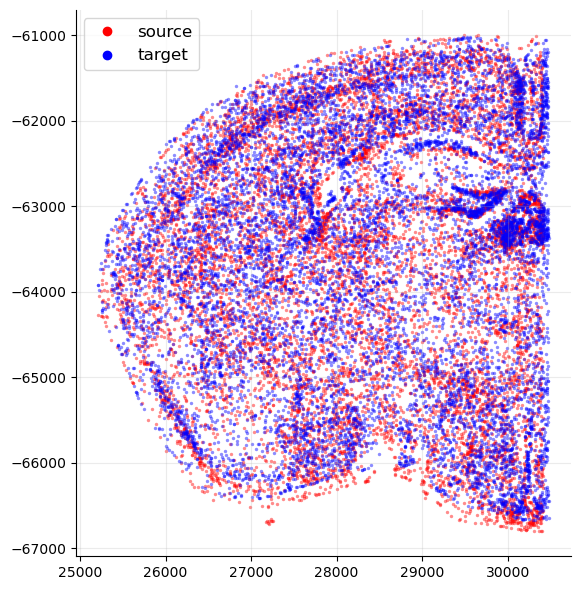

In [9]:
manta.plot.sampling(
    adatas=adatas,
    labels=["source", "target"],
    colors=["red", "blue"],
    sampling_key="sampling",

    figsize=(6, 6),
    alpha=0.45,
    marker_size=6,
    equal_aspect=True
)

### Embedding

An embedding can be obtained by through `manta.embedding.embed`. This will execute three steps:
 
1. Create a new feature per (subsampled) observation based on the PCA and NMF embeddings, as well as spatial features.
2. Embed the observations using a GraphSAGE encoder.
3. Cluster the observations in latent space.

**NOTE**: *Multiple tissue sections can be embedded simultaneously. This is especially helpful when aligning many tissue sections s.t. the embedding step only has to be performed once.*

In [10]:
manta.embedding.embed(
    adatas=adatas,

    spatial_key="rigid",
    sampling_key="sampling",

    pca_basis_key="X_pca",
    nmf_basis_key="X_nmf",

    # template_k represents the number of latent clusters we would like to represent
    template_k = 64
)

Computing Features:   0%|          | 0/3 [00:00<?, ?it/s]

Training:   0%|          | 0/25 [00:00<?, ?it/s]

For alignment, the embedding really doesn't have to be extremely accurate, just enough s.t. the spatial and molecular features are mixed together. The result of the embedding step is a clustering in the latent space, which can be visualized with `manta.plot.embedding`.

Computing UMAP...


/staging/leuven/stg_00002/lcb/mkovacic/conda_envs/manta312/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


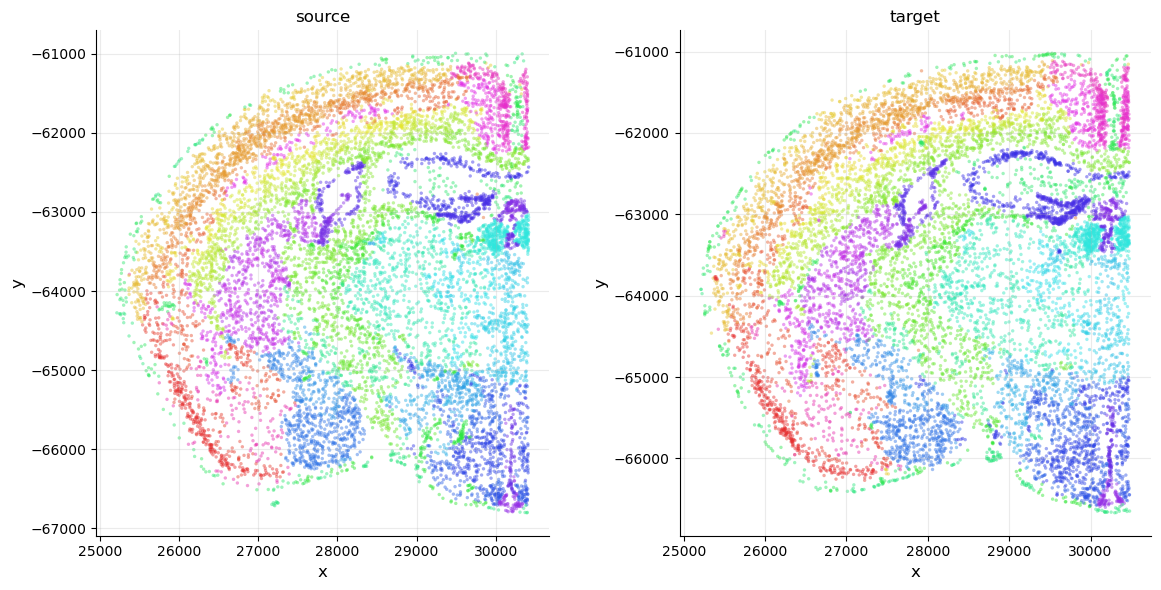

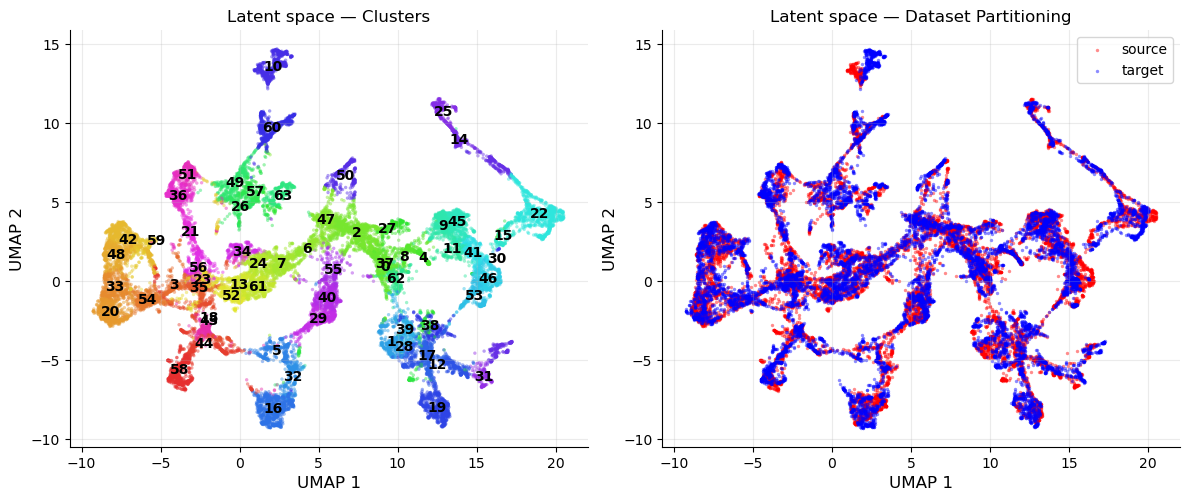

In [11]:
manta.plot.embedding(
    adatas=adatas,

    labels=["source", "target"],
    colors=["red", "blue"],

    cluster_figsize_per_panel=(6, 6),
    cluster_marker_size=6,
    cluster_alpha=0.45,

    latent_figsize=(12, 12),
    latent_marker_size=6,
    latent_alpha=0.45,
    
    equal_aspect=True
)

Individual clusters can be visualized using `manta.plot.cluster`. 

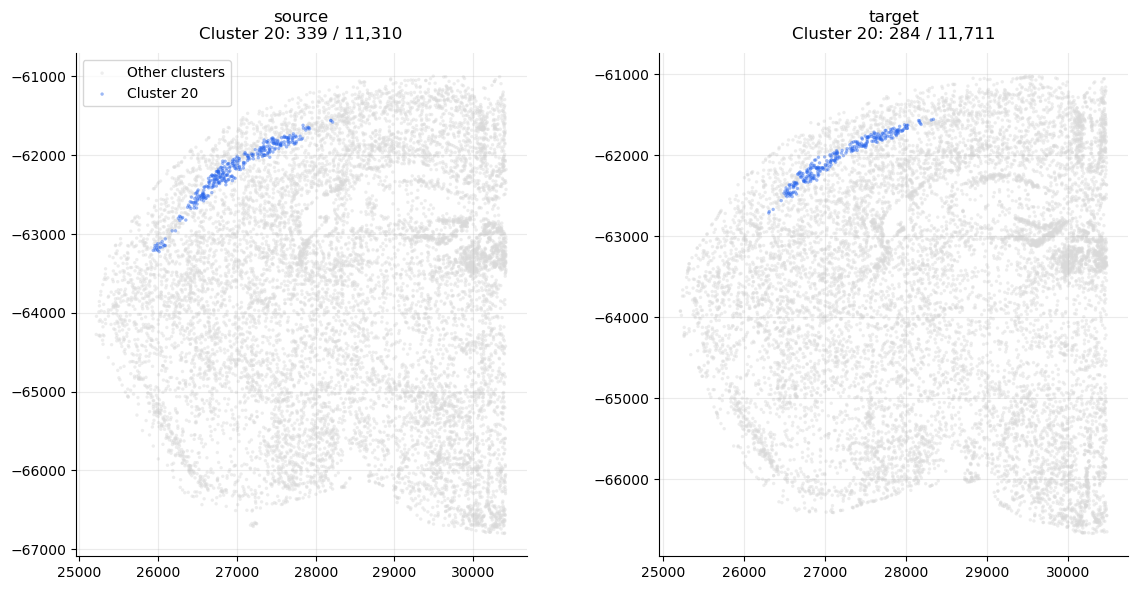

In [13]:
manta.plot.cluster(
    adatas=adatas,
    clusterId=20,
    
    labels=["source", "target"], 
    
    figsize_per_panel=(6,6),
    alpha=0.45,
    marker_size=6,
    equal_aspect=True
)

We can also plot a nearby cluster, e.g. cluster 33. Since the embedding combines both spatial and molecular features, we expect this cluster to be proximal to cluster 20.

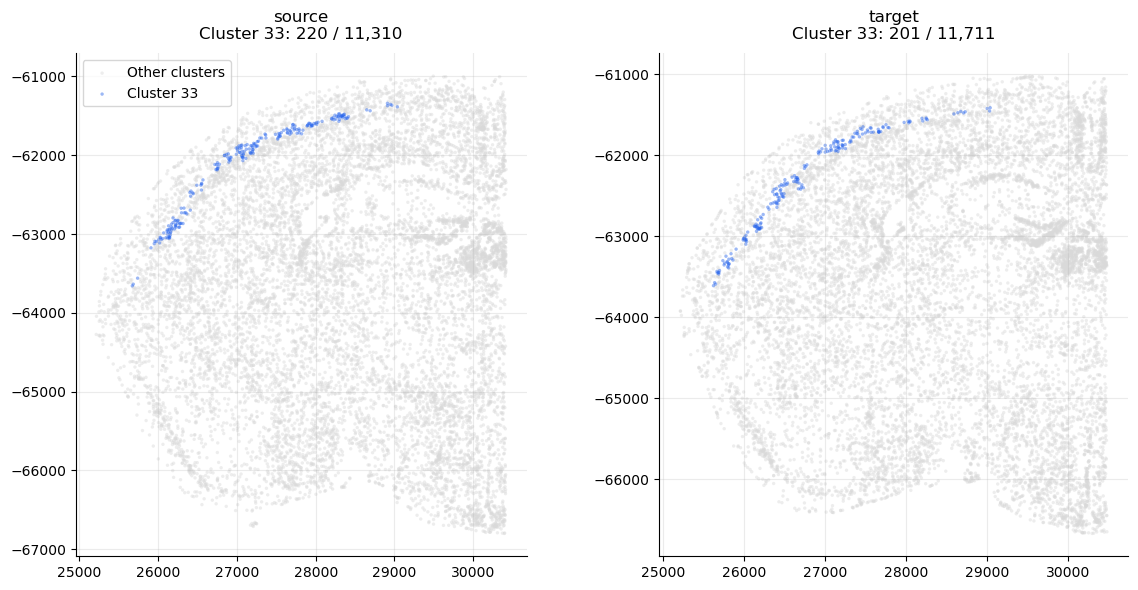

In [14]:
manta.plot.cluster(
    adatas=adatas,
    clusterId=33,
    
    labels=["source", "target"], 
    
    figsize_per_panel=(6,6),
    alpha=0.45,
    marker_size=6,
    equal_aspect=True
)

Similarly, we expect cluster 33 to divide cluster 20 and 48